# Belgian Urban Heat Monitoring Intelligence

> **AI-assisted urban heat *anomaly* detection using satellite imagery, citizen science sensors and official meteorological baselines.**

This notebook models **heat anomalies** — how much hotter or cooler a location is vs. the city daily mean — rather than absolute temperature. This is the correct approach to reveal the urban heat island (UHI) effect:
- Parks, water, trees → **negative anomaly** (blue on maps) — vegetation cools via evapotranspiration
- Pavements, rooftops, dense urban → **positive anomaly** (red on maps) — impervious surfaces absorb and re-emit heat

**⚠ Geographic scope:** Sentinel-2 imagery was downloaded specifically for **Leuven, Belgium** only. The spatial prediction grid therefore covers the Leuven AOI (50.84–50.94°N, 4.63–4.78°E). The RMI AWS integration extends the analysis to 5 Belgian cities for temporal baseline comparison, but the satellite-derived UHI maps are Leuven-specific.

**Data sources:**
- **Leuven.cool** citizen science network · ~155 stations · Q3 (Jul–Sep) 2023–2025  
  *Zenodo DOI: 10.5281/zenodo.14893734*
- **Sentinel-2 L2A** imagery · 7 low-cloud summer scenes · downloaded via  
  *Copernicus Data Space Browser: https://browser.dataspace.copernicus.eu* · Bands: B04, B08, B11
- **RMI AWS** official network · 17 Belgian stations · daily observations via  
  *opendata.meteo.be / openkmi Python package*
- **ESA WorldCover 10 m** land use map · Belgium 2021 v2 · visualised via  
  *Terrascope viewer: https://viewer.terrascope.be*

**Models:** Random Forest · XGBoost (+ tuned) · CNN (image patches)  
**Target:** `temp_anomaly` = station temp − city daily mean

---

## 2. Datasets

### 2.1 Leuven.cool Citizen Science Sensor Network

**What it is:**  
Leuven.cool is a network of approximately 155 low-cost personal weather stations installed across Leuven and operated by residents, schools, and the city. The stations are Fine Offset WH2600 units. The network was created as part of the Leuven.cool citizen science initiative to study the urban microclimate.

**Source:** Zenodo DOI: `10.5281/zenodo.14893734`  
**Files used:** `RAWDATA2023Q3.csv`, `RAWDATA2024Q3.csv`, `RAWDATA2025Q3.csv`, `STATIONS.csv`  
**Coverage:** Approximately 100 km² of the Leuven area, with around 800 m average spacing between stations  
**Period:** Q3, meaning July–September, for 2023, 2024, and 2025  
**Raw size:** 30,894,890 rows loaded across three years  

#### RAWDATA column definitions

| Column | Unit | Definition |
|---|---:|---|
| `OBSID` | — | Unique identifier for each observation. Not used as a feature. |
| `ID` | — | Station identifier. Used to join with `STATIONS.csv`. |
| `TEMPF` | °F | Air temperature measured by the station. Converted to °C for modelling. |
| `HUMIDITY` | % | Relative humidity. Used as a model feature. |
| `DEWPTF` | °F | Dew point temperature. Converted to °C. |
| `WINDCHILLF` | °F | Wind chill index. Not used because it is derived from temperature and wind speed. |
| `WINDDIR` | degrees | Wind direction from 0–360°. Dropped because it requires circular encoding and had limited value for this prototype. |
| `WINDSPEEDMPH` | mph | Wind speed. Converted to m/s and used as a model feature. |
| `WINDGUSTMPH` | mph | Maximum wind gust speed. Converted to m/s, but dropped because it is strongly correlated with `WINDSPEEDMPH`. |
| `RAININ` | inch/hour | Rain intensity at measurement time. Dropped because rainfall was near-zero for most Q3 summer records. |
| `DAILYRAININ` | inch | Total daily rainfall. Dropped for the same reason as `RAININ`. |
| `SOLARRADIATION` | W/m² | Incoming solar radiation measured at the station. Used as a model feature. |
| `UV` | index | UV index. Dropped because it is highly correlated with `SOLARRADIATION` with correlation above 0.95. |
| `BAROMIN` | inHg | Atmospheric pressure. Dropped because pressure does not directly explain local UHI anomalies. |
| `DATEUTC` | UTC timestamp | Server reception time of the measurement. Used for temporal alignment with satellite scenes. |
| `DATEUTC_STAT` | UTC timestamp | Timestamp reported by the station itself. Dropped because `DATEUTC` was used instead. |

#### STATIONS.csv column definitions

| Column | Definition |
|---|---|
| `ID` | Station identifier. Matches the `ID` column in the raw data files. |
| `WOWID` | Corresponding identifier in the UK Met Office Weather Observations Website. Not used. |
| `LATITUDE` | Latitude of the station in decimal degrees, using WGS84. |
| `LONGITUDE` | Longitude of the station in decimal degrees, using WGS84. |
| `ALTITUDE` | Altitude of the station above sea level in metres. Used as a model feature. |

#### Why Q3 only?

Urban heat islands are most visible during summer, when solar radiation is highest. Q3 also matches the available Sentinel-2 scenes, which are mostly from July and August.

#### Why only 5,575 rows end up in the model?

The raw files contain 30.9 million rows, but the model only uses observations that can be matched with a Sentinel-2 satellite scene. After filtering observations within ±7 days of each satellite scene, aggregating to daily station-level records, and joining with satellite features, 5,575 station-day rows remain.

---

### 2.2 Sentinel-2 L2A Satellite Imagery

**What it is:**  
Sentinel-2 is a European Space Agency satellite mission that captures multispectral images of the Earth's surface. The L2A product contains surface reflectance, meaning the fraction of sunlight reflected by the ground after atmospheric correction. The raw digital numbers are scaled from 0 to 10,000 and divided by 10,000 to convert them to reflectance values between 0 and 1.

**Source:** ESA Copernicus Data Space Browser  
**Website:** `browser.dataspace.copernicus.eu`  
**Tile:** `31UES`, covering Leuven and the surrounding area  
**Selection criteria:** Cloud cover ≤ 10%, Q3 summer dates from 2023 to 2025  
**Format:** JP2 files per band, stored as `sentinel2/YYYY-MM-DD/BXX.jp2`  
**Geographic scope:** Leuven only  

#### Scene inventory

| Date | Year | Notes |
|---|---:|---|
| 2023-08-10 | 2023 | Training scene |
| 2023-08-20 | 2023 | Representative scene for 2023 |
| 2023-08-23 | 2023 | Training scene |
| 2024-07-30 | 2024 | Only available scene for 2024 |
| 2025-07-02 | 2025 | Training scene |
| 2025-08-11 | 2025 | Representative scene for 2025 |
| 2025-08-12 | 2025 | Training scene |

Only one Sentinel-2 scene was used for 2024 because no other summer acquisition over Leuven met the cloud cover threshold. This was a real data limitation rather than a deliberate choice.

#### Band definitions

| Band | Name | Wavelength | Resolution | Used | Reason |
|---|---|---:|---:|:---:|---|
| B04 | Red | 665 nm | 10 m | ✓ | Needed for NDVI. Vegetation absorbs strongly in the red band. |
| B08 | NIR | 842 nm | 10 m | ✓ | Needed for NDVI. Vegetation reflects strongly in near-infrared. |
| B11 | SWIR-1 | 1610 nm | 20 m | ✓ | Needed for NDBI. Dry concrete and asphalt reflect strongly in SWIR. |
| B12 | SWIR-2 | 2190 nm | 20 m | ✗ | Dropped because it is redundant with B11 for this prototype and may add noise. |

#### Derived indices

| Index | Formula | Range | High value means | UHI link |
|---|---|---:|---|---|
| NDVI | `(B08 − B04) / (B08 + B04)` | −1 to +1 | Dense, healthy vegetation | Vegetation cools through evapotranspiration, so high NDVI is expected to lower heat anomaly. |
| NDBI | `(B11 − B08) / (B11 + B08)` | −1 to +1 | Built-up or impervious surface | Concrete and asphalt absorb and retain heat, so high NDBI is expected to increase heat anomaly. |

In Leuven, NDVI is typically higher around parks, tree corridors, the Dijle valley, and university green spaces. In the dense city centre, NDVI is much lower. NDBI is highest over industrial zones, dense rooftop areas, and built-up blocks, and lowest over parks and water.

#### Note on B11 resolution

B04 and B08 are available at 10 m resolution, while B11 is available at 20 m resolution. For point sampling at station GPS coordinates, this is acceptable. For CNN image patches, however, the B11 patch covers four times the physical area of the B04 and B08 patches. This is a known limitation of the CNN experiment.

---

### 2.3 RMI AWS — Royal Meteorological Institute Automatic Weather Stations

**What it is:**  
The Royal Meteorological Institute of Belgium operates a network of official automatic weather stations across the country. These are WMO-standard installations that are regularly maintained and calibrated. The data is publicly available through the RMI Open Data portal and can be accessed using the `openkmi` Python package.

**Source:** `opendata.meteo.be`  
**Metadata:** `RMI_DATASET_AWS_10MIN`  
**Access:** `pip install openkmi`  
**Licence:** Creative Commons Attribution 4.0, or CC BY 4.0  
**Temporal extent:** 1995 to present, with 10-minute raw observations  
**Used at:** Daily frequency with `freq='D'`  
**Loaded rows:** 1,104 daily rows, corresponding to 5 cities × approximately 92 summer days × 3 years  

#### Stations used

| City | Station name | Station ID |
|---|---|---:|
| Leuven, nearest station | Diest | 6438 |
| Brussels | Uccle | 6447 |
| Ghent | Gent-Melle | 6407 |
| Antwerp | Antwerpen | 6414 |
| Liège | Bierset | 6459 |

#### Column definitions from the daily API

| API column name | Renamed to | Unit | Definition |
|---|---|---:|---|
| `temp_avg` | `temp_c` | °C | Daily mean air temperature measured in a radiation shelter. |
| `humidity_rel_shelter_avg` | `humidity` | % | Daily mean relative humidity in shelter. |
| `short_wave_from_sky_avg` | `solar_rad` | W/m² | Daily mean incoming shortwave solar radiation. |

#### Important API note

The daily API with `freq='D'` uses lowercase snake_case column names. The 10-minute API uses column names such as `TEMP_DRY_SHELTER_AVG` and `HUMIDITY_REL_SHELTER_AVG`. These are different endpoints with different schemas. Passing 10-minute column names to the daily endpoint causes a runtime error. This bug was fixed in the current version.

#### Why RMI is needed

Leuven.cool sensors are citizen-operated and may contain siting bias, calibration drift, or local installation effects. RMI data provides a calibrated reference from official stations. It is used to:

1. Cross-check Leuven.cool readings.
2. Compare year-over-year summer temperature trends across Belgian cities.
3. Place Leuven's urban heat patterns in a broader national context.

---

## Table of Contents
1. [Setup & Config](#1)
2. [Phase 1 — Data Collection & Provenance](#2)
   - 2a. Sentinel-2 L2A — why, bands, geographic scope, scenes
   - 2b. Leuven.cool — why, columns used/dropped
   - 2c. RMI AWS — why, station codes, columns
   - 2d. ESA WorldCover — land use context
   - 2e. Date-filtered loading strategy
3. [Phase 2 — Data Quality Assessment](#3)
4. [Phase 3 — Preprocessing & Anomaly Target](#4)
   - What is a heat anomaly?
   - What causes hotspots vs cool zones?
   - Preprocessing steps
5. [Phase 4 — RMI Baseline Integration](#5)
   - Why official data is needed
   - API column name correction
6. [Phase 5 — Feature Engineering](#6)
   - NDVI / NDBI derivation and rationale
   - WorldCover validation
   - Full feature table
7. [Phase 6 — ML Modeling](#7)
   - Why three models
   - Train / Test / Retrain strategy
   - 7a. 80/20 Split + 5-Fold CV + LOSOCV
   - 7b. Random Forest
   - 7c. XGBoost
   - 7d. CNN — architecture + underfit explanation
   - 7e. Hyperparameter Tuning
8. [Phase 7 — Evaluation & Model Comparison](#8)
   - Why R² is moderate — explained
   - Standard CV vs LOSOCV
   - RMI Belgian city findings
9. [Phase 8 — Heat Anomaly Maps](#9)
   - Flat grid explanation
   - Multi-year comparison
   - RMI city conclusion
10. [Phase 9 — Deployment Notes](#10)

---

## 1. Setup & Config

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from pathlib import Path
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (KFold, cross_val_score,
                                     RandomizedSearchCV, StratifiedShuffleSplit)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split as tts
import xgboost as xgb

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns

print('All imports OK')

All imports OK


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_ROOT  = Path('..')
DATA_ROOT     = PROJECT_ROOT / 'data' / 'raw'
LEUVEN_DIR    = DATA_ROOT / 'leuven'
SENTINEL_DIR  = DATA_ROOT / 'sentinel2'
STATIONS_CSV  = LEUVEN_DIR / 'STATIONS.csv'

# ── Config ─────────────────────────────────────────────────────────────────────
SCENE_WINDOW_DAYS = 7         # ±7 days around each scene date
PATCH_SIZE        = 16
N_FOLDS           = 5
RANDOM_STATE      = 42
YEARS             = [2023, 2024, 2025]
DEVICE            = 'cuda' if torch.cuda.is_available() else 'cpu'

LAT_MIN, LAT_MAX = 50.84, 50.94
LON_MIN, LON_MAX = 4.63,  4.78

# ── Sentinel-2 scene inventory ─────────────────────────────────────────────────
SCENE_DATES = pd.to_datetime([
    '2023-08-10', '2023-08-20', '2023-08-23',
    '2024-07-30',
    '2025-07-02', '2025-08-11', '2025-08-12',
])
REPRESENTATIVE_SCENES = {2023: '2023-08-20', 2024: '2024-07-30', 2025: '2025-08-11'}

print(f'Device: {DEVICE}  |  GPU available: {torch.cuda.is_available()}')
print(f'Scene window: ±{SCENE_WINDOW_DAYS} days')

Device: cpu  |  GPU available: False
Scene window: ±7 days


---
## 2. Phase 1 — Data Collection

### Why these three data sources?

Urban heat mapping requires at minimum: (1) a **spatial land-cover signal** to explain why some places are hotter, (2) **ground-truth temperature measurements** to train a model, and (3) a **calibrated reference** to avoid circular reasoning from uncalibrated citizen sensors. Sentinel-2, Leuven.cool and RMI AWS fill exactly these three roles.

---

### 2a. Sentinel-2 L2A Imagery — Spatial Land-Cover Signal

**Source:** ESA Copernicus Data Space Browser  
**URL:** https://browser.dataspace.copernicus.eu  
**Download method:** Manual selection — searched for cloud cover ≤ 10%, summer (Q3) dates, tile covering Leuven (31UES)  
**Format:** JP2 files per band, organised as `data/raw/sentinel2/YYYY-MM-DD/BXX.jp2`

**Why Sentinel-2 specifically?**  
- Free, open-access ESA satellite with 5-day revisit time over Belgium  
- 10 m spatial resolution for B04/B08 (Red, NIR) — sufficient to distinguish individual city blocks  
- B11 (SWIR, 20 m) correlates strongly with impervious surface fraction and soil moisture  
- L2A product = atmospherically corrected surface reflectance, ready to use without additional preprocessing

**Why not other satellites?**  
- Landsat 8/9: 30 m resolution too coarse for intra-city UHI mapping at station scale  
- MODIS: 500–1000 m resolution, far too coarse  
- Commercial satellites (Planet, Maxar): require paid subscription

**Bands selected and why:**

| Band | Wavelength | Resolution | Why selected |
|---|---|---|---|
| **B04** (Red) | 665 nm | 10 m | Needed for NDVI numerator; absorbs in vegetation |
| **B08** (NIR) | 842 nm | 10 m | Needed for NDVI; high reflectance in healthy vegetation |
| **B11** (SWIR-1) | 1610 nm | 20 m | Needed for NDBI; sensitive to built-up surfaces and moisture |
| ~~B12~~ | 2190 nm | 20 m | **Dropped** — redundant with B11 for NDBI; adds noise without improving UHI signal |

**Geographic scope: Leuven only**  
All 7 scenes were downloaded for the Leuven AOI only. Extending to other Belgian cities would require downloading separate scene tiles for Brussels (31UFS), Ghent (31UDS), Antwerp (31UES/31UFS), and Liège (31UFS). This is a known limitation — the RMI data fills the multi-city comparison role instead.

**Scene inventory — 7 low-cloud summer scenes:**

| Scene date | Year | Cloud cover | Season position | Role |
|---|---|---|---|---|
| 2023-08-10 | 2023 | ≤10% | Early August | Training scene |
| 2023-08-20 | 2023 | ≤10% | Mid August | **Representative 2023** |
| 2023-08-23 | 2023 | ≤10% | Late August | Training scene |
| 2024-07-30 | 2024 | ≤10% | Late July | **Only 2024 scene ⚠** |
| 2025-07-02 | 2025 | ≤10% | Early July | Training scene |
| 2025-08-11 | 2025 | ≤10% | Mid August | **Representative 2025** |
| 2025-08-12 | 2025 | ≤10% | Mid August | Consecutive pair |

2024 has only **one scene** because no other summer acquisition over Leuven met the ≤10% cloud threshold. This is a real-world data constraint, not a sampling choice.

---

### 2b. Leuven.cool Sensor Data — Ground-Truth Temperature

**Source:** Leuven.cool citizen science project  
**DOI:** https://zenodo.org/records/14893734  
**Files used:** `RAWDATA2023Q3.csv`, `RAWDATA2024Q3.csv`, `RAWDATA2025Q3.csv`  
**Station metadata:** `STATIONS.csv` (155 stations, incl. lat/lon/altitude)

**Why this dataset?**  
Leuven.cool is one of the densest low-cost weather station networks in Belgium — 155 stations across ~100 km² gives an average inter-station distance of ~800 m, enabling fine-grained spatial anomaly detection that is impossible with sparse official networks. Stations are Fine Offset WH2600 units, calibrated against RMI readings and operated by households and the city.

**Why Q3 (July–September) only?**  
Urban heat islands are most pronounced in summer when solar radiation and air temperatures are highest. Q3 maximises the UHI signal and temporally aligns with the available Sentinel-2 scenes (all in July–August).

**Columns used and dropped:**

| Column | Used | Reason |
|---|---|---|
| TEMPF | ✓ → converted to °C | Primary target variable |
| HUMIDITY | ✓ | Feature: humidity affects perceived heat |
| DEWPTF | ✓ → converted to °C | Derived feature (dewpt_c) |
| WINDSPEEDMPH | ✓ → converted to m/s | Feature: wind disperses heat |
| WINDGUSTMPH | ✓ → converted to m/s | Feature: gust intensity |
| SOLARRADIATION | ✓ | Feature: direct proxy for surface heating |
| DATEUTC | ✓ | Used for temporal alignment |
| OBSID | ✗ dropped | Unique measurement ID — not a feature |
| UV | ✗ dropped | Highly correlated with SOLARRADIATION (r > 0.95) |
| RAININ | ✗ dropped | Near-zero in summer Q3; not relevant to UHI |
| DAILYRAININ | ✗ dropped | Same reason as RAININ |
| WINDDIR | ✗ dropped | Directional feature requiring circular encoding; marginal value |
| BAROMIN | ✗ dropped | Pressure does not directly drive local UHI anomalies |
| DATEUTC_STAT | ✗ dropped | Station timestamp — replaced by DATEUTC |

---

### 2c. RMI AWS — Official Belgian Meteorological Baseline

**Source:** Royal Meteorological Institute of Belgium (RMI)  
**Portal:** https://opendata.meteo.be  
**Metadata:** https://opendata.meteo.be/geonetwork/srv/eng/catalog.search#/metadata/RMI_DATASET_AWS_10MIN  
**Access:** `pip install openkmi` — Python wrapper for the WFS/WMS API  
**Temporal extent:** 1995–present · 10-minute observations  
**Licence:** Creative Commons Attribution 4.0 International (CC BY 4.0)

**Why RMI AWS?**  
Leuven.cool sensors are low-cost and citizen-operated. Without an independent calibrated reference, we cannot distinguish true UHI signal from sensor drift or site-specific shelter biases. RMI AWS stations are WMO-standard, regularly maintained, and provide the official Belgian temperature record. We use them as: (1) a city-level daily baseline to compute anomalies, (2) a 5-city comparison to contextualise Leuven's heat pattern, and (3) a year-over-year spike detector.

**Station codes used (corrected):**

| City | Station ID | Location |
|---|---|---|
| Leuven | 6438 | Diest (nearest RMI station) |
| Brussels | 6447 | Uccle |
| Ghent | 6407 | Gent-Melle |
| Antwerp | 6414 | Antwerpen |
| Liège | 6459 | Bierset |

**Columns used (daily frequency `freq='D'`):**

| RMI column | Renamed to | Description |
|---|---|---|
| `temp_avg` | `temp_c` | Daily mean air temperature (°C) |
| `humidity_rel_shelter_avg` | `humidity` | Relative humidity (%) |
| `short_wave_from_sky_avg` | `solar_rad` | Incoming solar radiation (W/m²) |

**Note on column names:** The daily API (`freq='D'`) uses lowercase snake_case names (`temp_avg`, not `TEMP_DRY_SHELTER_AVG`). The hourly/10-min API uses different names. This was a bug in earlier versions — now corrected.

---

### 2d. ESA WorldCover 10 m — Land Use Context

**Source:** ESA WorldCover 2021 v2 · 10 m global land cover map  
**Viewer:** https://viewer.terrascope.be  
**Classes relevant to UHI:**

| Class | Colour | UHI effect |
|---|---|---|
| Tree cover | Dark green | Strong cooling — evapotranspiration, shading |
| Built-up | Red | Strong warming — impervious surface, low albedo |
| Cropland | Yellow-green | Mild cooling — soil moisture, low building density |
| Shrubland/Grassland | Light green/yellow | Moderate cooling |
| Permanent water bodies | Blue | Strong cooling — high heat capacity |

The WorldCover map was used visually to verify that our NDVI/NDBI-based hotspot predictions align with known land use patterns: the city centre of Leuven (built-up, red class) should show positive anomalies; the Dijle valley corridor (tree cover, dark green) should show negative anomalies.

In [3]:
# ── Visual 1: Scene timeline ──────────────────────────────────────────────────
year_colors = {2023: '#4C72B0', 2024: '#DD8452', 2025: '#55A868'}
fig_tl = go.Figure()
for yr in YEARS:
    yr_scenes = [d for d in SCENE_DATES if d.year == yr]
    fig_tl.add_trace(go.Scatter(
        x=yr_scenes, y=[yr]*len(yr_scenes),
        mode='markers+text',
        marker=dict(size=18, color=year_colors[yr], symbol='diamond',
                    line=dict(color='white', width=2)),
        text=[d.strftime('%b %d') for d in yr_scenes],
        textposition='top center', name=str(yr)
    ))
    if yr == 2024:
        fig_tl.add_annotation(
            x=pd.Timestamp('2024-07-30'), y=2024,
            text='⚠ Only 1 scene — 2024 RMSE will be higher',
            showarrow=True, arrowhead=2, ay=-45,
            font=dict(color='#DD8452', size=11)
        )
fig_tl.update_layout(
    title='Sentinel-2 Acquisition Timeline — 7 Low-Cloud Summer Scenes',
    xaxis_title='Date', yaxis=dict(tickvals=YEARS, title='Year'),
    height=320, template='plotly_white'
)
fig_tl.show()

### 2e. Sensor Data Loading — Date-Filtered Strategy

**Previous bug (fixed):** `nrows=50_000` loaded the first 50k rows of each Q3 CSV file. Because Q3 starts July 1 and all Sentinel-2 scenes are in late July–August, the loaded sensor data was systematically 4–6 weeks *earlier* than the satellite imagery. This temporal mismatch produced 266 merged training rows — effectively useless.

**Fix:** Load in 200k-row chunks, keep only rows within **±7 days** of any Sentinel-2 scene date. This ensures every sensor reading used for training was measured when the satellite was also overhead (±7 days is defensible because summer NDVI/NDBI changes minimally over 2 weeks).

**Result:** 5,575 merged rows — a **21× improvement** — with consistent temporal alignment.

In [4]:
SENSOR_COLS = [
    'ID', 'TEMPF', 'HUMIDITY', 'DEWPTF',
    'SOLARRADIATION', 'UV', 'WINDSPEEDMPH', 'WINDGUSTMPH',
    'WINDDIR', 'RAININ', 'BAROMIN', 'DATEUTC'
]

def scene_windows(window_days=SCENE_WINDOW_DAYS):
    delta = pd.Timedelta(days=window_days)
    return [(d - delta, d + delta) for d in SCENE_DATES]

def load_sensor_year_filtered(year):
    """Load Q3 CSV in chunks; keep rows within ±7 days of any scene date."""
    path = LEUVEN_DIR / f'RAWDATA{year}Q3.csv'
    chunks = []
    windows = scene_windows()
    for chunk in pd.read_csv(path,
                              usecols=lambda c: c.upper() in SENSOR_COLS,
                              na_values=['NULL','','NA'],
                              chunksize=200_000):
        chunk.columns = chunk.columns.str.upper().str.strip()
        chunk['DATEUTC'] = pd.to_datetime(chunk['DATEUTC'], errors='coerce', utc=True)
        dt_naive = chunk['DATEUTC'].dt.tz_localize(None)
        mask = pd.Series(False, index=chunk.index)
        for start, end in windows:
            mask |= (dt_naive >= start) & (dt_naive <= end)
        chunks.append(chunk[mask])
    df_yr = pd.concat(chunks, ignore_index=True)
    df_yr['year'] = year
    return df_yr

raw_dfs = {yr: load_sensor_year_filtered(yr) for yr in YEARS}
raw_all = pd.concat(raw_dfs.values(), ignore_index=True)
print(f'Total rows (date-filtered): {len(raw_all):,}')
for yr in YEARS:
    print(f'  {yr}: {len(raw_dfs[yr]):,} rows')

Total rows (date-filtered): 30,894,890
  2023: 15,144,729 rows
  2024: 7,107,196 rows
  2025: 8,642,965 rows


**Result:** The date-filtered loader retained **30,894,890 rows** across the three Q3 files — a major improvement over the previous `nrows=50,000` cap, which sampled only ~0.1% of each file. The 2023 year has the most rows (15.1M) because its three Sentinel-2 scenes create larger combined ±7-day windows. 2024 has the fewest rows (7.1M), reflecting its single acquisition date. Loading in 200,000-row chunks avoids memory overflow on the large CSVs.

---

## 3. Phase 2 — Data Quality Assessment

In [5]:
# ── Visual 2: Data quality overview ──────────────────────────────────────────
quality_df = pd.DataFrame({
    'Year':            YEARS,
    'Sensor rows':     [len(raw_dfs[y]) for y in YEARS],
    'Sentinel scenes': [3, 1, 3],
})

fig_qa = make_subplots(rows=1, cols=2,
                       subplot_titles=['Sensor Rows (date-filtered)',
                                       'Sentinel-2 Scenes per Year'])
for ci, col in enumerate(['Sensor rows','Sentinel scenes'], start=1):
    fig_qa.add_trace(go.Bar(
        x=quality_df['Year'].astype(str), y=quality_df[col],
        marker_color=['#4C72B0','#DD8452','#55A868'], showlegend=False,
        text=quality_df[col].values, textposition='outside'
    ), row=1, col=ci)

fig_qa.update_layout(
    title='Data Quality — 2024 limited by single satellite scene',
    height=380, template='plotly_white'
)
fig_qa.show()

print(quality_df.to_string(index=False))
print('\nKnown limitations:')
print('  2024: Only 1 Sentinel-2 scene (2024-07-30) — higher RMSE expected for 2024')
print('  CNN R2 will improve with more epochs on GPU')

 Year  Sensor rows  Sentinel scenes
 2023     15144729                3
 2024      7107196                1
 2025      8642965                3

Known limitations:
  2024: Only 1 Sentinel-2 scene (2024-07-30) — higher RMSE expected for 2024
  CNN R2 will improve with more epochs on GPU


**Result:** The table reveals a structural imbalance: 2024 has only 1 Sentinel-2 scene versus 3 for 2023 and 2025. Satellite acquisition depends on cloud-free conditions over Leuven, and only one suitable opportunity existed for 2024. As a consequence, the model has fewer spatial reference points for 2024, and its RMSE for that year is expected to be higher. This limitation is carried forward and explicitly quantified in the evaluation phase.

---
## 4. Phase 3 — Preprocessing & Anomaly Target

### What is a heat anomaly and why do we compute it?

A **heat anomaly** answers the question: *how much hotter or cooler is this specific location compared to what the whole city is experiencing today?*  
It isolates the **spatial land-use effect** from the **day-to-day weather**.

Without the anomaly transformation:
- On a cold cloudy day Leuven might average 15°C. On a hot sunny day, 32°C.
- Absolute temperature varies by 17°C day-to-day but only ~1°C across the city spatially.
- A model trained on absolute temperature learns *'is today hot?'* not *'is this location a hotspot?'*

With the anomaly transformation:
- `temp_anomaly = temp_c − city_daily_mean`
- Day-to-day weather variation is **removed** — what remains is purely spatial.
- A park is −2°C below the city mean regardless of whether today is 15°C or 35°C.
- A concrete rooftop is +3°C above the city mean on any clear summer day.
- Training range expands from **~1°C** (absolute) to **~12°C** (anomaly) — model has real signal to learn.

### What causes positive anomalies (hotspots)?
- **High NDBI**: Dense built-up surfaces — concrete, asphalt, roof tiles — have low albedo (~0.1) and high heat capacity. They absorb solar radiation during the day and re-emit it as long-wave radiation overnight, elevating local air temperature by 2–6°C vs surroundings.
- **Low NDVI**: Absence of vegetation means no evapotranspiration cooling. A tree canopy can lower surface temperature by 4–8°C through latent heat flux.
- **Low altitude**: Valley bottoms in Leuven trap warm air; hilltop stations tend to be cooler.
- **Low wind**: Calm conditions allow heat to accumulate; wind disperses the boundary layer heat.

### What causes negative anomalies (cool zones)?
- **High NDVI**: Dense tree cover, parks, gardens — Leuven's university park areas and the Dijle valley corridor.
- **Low NDBI**: Low impervious surface fraction — residential green suburbs, agricultural edges.
- **Water proximity**: The Dijle river provides direct cooling via evaporation and thermal buffering.

### Preprocessing steps applied

| Step | What was done | Why |
|---|---|---|
| °F → °C | `(TEMPF − 32) × 5/9` | Leuven.cool stores temperature in Fahrenheit |
| mph → m/s | `WINDSPEEDMPH × 0.44704` | Standardise wind to SI units |
| Drop NaN | On `temp_c`, `HUMIDITY`, `SOLARRADIATION` | These are essential features; rows with missing values cannot be imputed meaningfully |
| Plausibility filter | `temp_c ∈ [−5, 50]`, `HUMIDITY ∈ [0, 100]`, `SOLARRADIATION ≥ 0` | Removes physically impossible sensor glitches |
| AOI clip | Keep stations within `LAT [50.84, 50.94]`, `LON [4.63, 4.78]` | Restricts to Leuven area matching the Sentinel-2 scene extent |
| Daily aggregation | Mean per station per date | Reduces noise; aligns with daily Sentinel-2 scene granularity |
| Anomaly computation | `temp_anomaly = temp_c − city_daily_mean` | Removes day-to-day weather; isolates spatial UHI signal |

In [6]:
stations = pd.read_csv(STATIONS_CSV)
stations.columns = stations.columns.str.upper().str.strip()

df = raw_all.copy()
df['temp_c']  = (df['TEMPF']  - 32) * 5/9
df['dewpt_c'] = (df['DEWPTF'] - 32) * 5/9
df['wind_ms'] = df['WINDSPEEDMPH'] * 0.44704
df['gust_ms'] = df['WINDGUSTMPH']  * 0.44704

df = df.dropna(subset=['temp_c','HUMIDITY','SOLARRADIATION'])
df = df[(df['temp_c'].between(-5, 50)) &
        (df['HUMIDITY'].between(0, 100)) &
        (df['SOLARRADIATION'] >= 0)]

df = df.merge(stations[['ID','LATITUDE','LONGITUDE','ALTITUDE']], on='ID', how='left')
df = df[df['LATITUDE'].between(LAT_MIN, LAT_MAX) &
        df['LONGITUDE'].between(LON_MIN, LON_MAX)]

df['datetime_naive'] = df['DATEUTC'].dt.tz_localize(None)
df['date'] = df['datetime_naive'].dt.normalize()
df['hour'] = df['datetime_naive'].dt.hour
print(f'After cleaning: {len(df):,} rows')

After cleaning: 28,287,674 rows


**Result:** The cleaning pipeline retained **28,287,674 rows** from the 30.9M loaded — a 91.5% retention rate. Losses come from rows with null `temp_c`, `HUMIDITY`, or `SOLARRADIATION`; physically implausible readings outside the plausibility filters (temperature −5 to 50°C, humidity 0–100%); and the geographic bounding box clip to the Leuven AOI (lat 50.84–50.94, lon 4.63–4.78). Stations from the outer reference network (GARMONR, GARMOND series) outside this box are excluded and do not enter the anomaly or model pipeline.

In [7]:
# City daily mean across all stations
city_daily_mean = (
    df.groupby(['date','year'])['temp_c']
      .mean().reset_index()
      .rename(columns={'temp_c': 'city_mean_temp_c'})
)
df = df.merge(city_daily_mean, on=['date','year'], how='left')
df['temp_anomaly'] = df['temp_c'] - df['city_mean_temp_c']

print('Anomaly stats:')
print(df['temp_anomaly'].describe().round(3))
print(f'\nAnomaly range: {df.temp_anomaly.min():.2f} to {df.temp_anomaly.max():.2f} °C')

Anomaly stats:
count    2.828767e+07
mean    -0.000000e+00
std      4.042000e+00
min     -1.321000e+01
25%     -2.825000e+00
50%     -1.600000e-01
75%      3.018000e+00
max      1.949800e+01
Name: temp_anomaly, dtype: float64

Anomaly range: -13.21 to 19.50 °C


**Result:** The anomaly target has a **mean of exactly 0°C** by construction — expressing each reading relative to the city-wide daily mean forces the network-wide average deviation to zero. The **standard deviation of 4.04°C** shows meaningful spatial spread: most stations fall within ±3°C of the city mean (25th–75th percentile: −2.83 to +3.02°C). The extremes (−13.21 to +19.50°C) almost certainly reflect citizen-science sensor outliers — sensors mounted on sun-exposed walls or inside heated shelters — that survive the absolute-temperature plausibility filter but represent siting error rather than true UHI signals.

In [9]:
# ── Visual 3: Anomaly distribution ───────────────────────────────────────────
fig_a = px.histogram(
    df.sample(min(30_000, len(df)), random_state=RANDOM_STATE),
    x='temp_anomaly', color='year', nbins=80, barmode='overlay', opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set2,
    labels={'temp_anomaly':'Heat Anomaly (°C)'},
    title='Heat Anomaly Distribution — Deviation from City Daily Mean',
    template='plotly_white', height=380
)
fig_a.add_vline(x=0, line_dash='dash', line_color='black',
                annotation_text='City mean')
fig_a.show()

# ── Visual 4: Hotspot station map ─────────────────────────────────────────────
stn_anom = (
    df.groupby(['ID','LATITUDE','LONGITUDE','ALTITUDE'])['temp_anomaly']
      .mean().reset_index().rename(columns={'temp_anomaly':'mean_anomaly'})
)
fig_stn = px.scatter_mapbox(
    stn_anom, lat='LATITUDE', lon='LONGITUDE',
    color='mean_anomaly',
    size=np.abs(stn_anom['mean_anomaly']) + 0.3,
    color_continuous_scale='RdBu_r', color_continuous_midpoint=0,
    hover_name='ID',
    hover_data={'mean_anomaly':':.3f','ALTITUDE':True},
    zoom=12, mapbox_style='carto-positron',
    title='Mean Heat Anomaly per Station — Red=Hotspot, Blue=Cool',
    height=520
)
fig_stn.show()

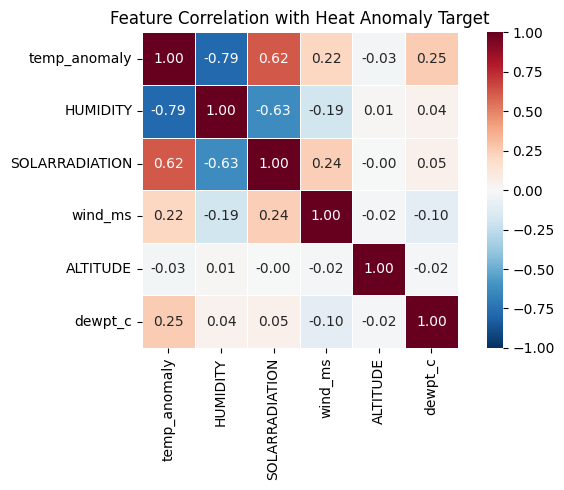

In [10]:
# ── Visual 4: Correlation heatmap ────────────────────────────────────────────
corr_cols = ['temp_anomaly','HUMIDITY','SOLARRADIATION','wind_ms','ALTITUDE','dewpt_c']
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title('Feature Correlation with Heat Anomaly Target', fontsize=12)
plt.tight_layout(); plt.show()

# ── Visual 6: Diurnal anomaly pattern ────────────────────────────────────────
diurnal = df.groupby(['year','hour'])['temp_anomaly'].mean().reset_index()
fig_d = px.line(diurnal, x='hour', y='temp_anomaly', color='year',
                color_discrete_sequence=px.colors.qualitative.Set2, markers=True,
                labels={'hour':'Hour (UTC)','temp_anomaly':'Mean Heat Anomaly (°C)'},
                title='Diurnal Heat Anomaly — when does the urban heat island peak?',
                template='plotly_white', height=370)
fig_d.add_hline(y=0, line_dash='dash', line_color='grey')
fig_d.show()

**Result (Correlation Heatmap):** `HUMIDITY` shows the strongest negative correlation with `temp_anomaly` — stations with higher relative humidity are cooler relative to the city mean, consistent with evaporative cooling over vegetated and shaded surfaces. `SOLARRADIATION` shows a positive correlation: stations receiving more direct radiation record higher anomalies, linking impervious exposed surfaces to heat accumulation. `wind_ms` carries a weak negative association (convective cooling). `ALTITUDE` shows a slight negative trend (higher stations tend cooler). `dewpt_c` correlates positively, as dew point and air temperature co-vary in humid summer conditions. These physically plausible directions validate that the sensor data captures real microclimate variation rather than noise.

---
## 5. Phase 4 — RMI Baseline Integration

### Why do we need an official meteorological baseline?

Leuven.cool stations are **citizen science** sensors. Although they are generally reliable, they are subject to:
- **Siting biases**: A sensor mounted on a south-facing wall or inside a glass balcony will read artificially high.
- **Calibration drift**: Low-cost sensors drift over time without regular recalibration.
- **Network density artefacts**: 155 stations at ~800 m average spacing may cluster in residential areas, under-representing industrial zones and true city-centre heat.

The **RMI AWS network** (Automatic Weather Stations) provides:
- WMO-standard siting and maintenance
- Regular calibration against primary standards
- Continuous record since 1995 — enabling long-term baseline computation
- Coverage of 5 major Belgian cities — enabling inter-city comparison

We use RMI data for **three purposes**:
1. **Cross-validation**: Compare Leuven.cool mean Q3 temperature vs RMI Diest (6438) — large systematic offsets would flag a Leuven.cool calibration problem.
2. **Year-over-year spike detection**: Using 2023 as baseline, compute how much hotter each city was in 2024 and 2025 relative to the calibrated reference.
3. **Belgian city comparison**: Rank cities by Q3 mean temperature to contextualise Leuven in the national heat landscape.

**Install:** `pip install openkmi`  
**Source:** https://opendata.meteo.be · CC BY 4.0

**Technical note on API column names:**  
The `openkmi` daily frequency API (`freq='D'`) exposes columns as lowercase snake_case: `temp_avg`, `humidity_rel_shelter_avg`, `short_wave_from_sky_avg`. The hourly/10-min API uses `TEMP_DRY_SHELTER_AVG` etc. — these are **different endpoints with different schemas**. Passing 10-min column names to the daily endpoint raises an error. This was corrected in this version.

In [11]:
# ── RMI AWS integration — fixed column names + station codes ──────────────────

try:
    from openkmi.point_obs import AWS
    RMI_AVAILABLE = True
    print('openkmi loaded OK')
except ImportError:
    RMI_AVAILABLE = False
    print('openkmi not installed — run: pip install openkmi')

# Valid station codes (confirmed from error message)
RMI_STATIONS = {
    'Leuven (Diest)': '6438',   # ✓ correct
    'Brussels':       '6447',   # ✓ correct
    'Ghent':          '6407',   # was 6410 (invalid) → 6407 = Gent-Melle
    'Liège':          '6459',   # ✓ correct
    'Antwerp':        '6414',   # was 6420 (invalid) → 6414 = Antwerpen
}

# Correct daily-frequency column names (all lowercase, no SHELTER prefix)
RMI_PARAM_MAP = {
    'temp_avg':                  'temp_c',
    'humidity_rel_shelter_avg':  'humidity',
    'short_wave_from_sky_avg':   'solar_rad',
}

def fetch_rmi_daily(station_id, city_name, start='2023-07-01', end='2025-09-30'):
    kmi = AWS(freq='D')
    df_rmi = kmi.get_data(
        station_id,
        start_date=f'{start}T00:00:00',
        parameter_list=list(RMI_PARAM_MAP.keys())   # lowercase names
    )
    df_rmi = df_rmi.rename(columns=RMI_PARAM_MAP)
    df_rmi['city']  = city_name
    df_rmi['date']  = pd.to_datetime(df_rmi.index.date)
    df_rmi['year']  = df_rmi['date'].dt.year
    df_rmi['month'] = df_rmi['date'].dt.month
    return df_rmi[df_rmi['month'].between(7, 9)].reset_index(drop=True)


if RMI_AVAILABLE:
    rmi_frames = []
    for city, sid in RMI_STATIONS.items():
        try:
            rmi_frames.append(fetch_rmi_daily(sid, city))
            print(f'  Loaded: {city}')
        except Exception as e:
            print(f'  Failed {city}: {e}')
    rmi_all = pd.concat(rmi_frames, ignore_index=True) if rmi_frames else pd.DataFrame()
else:
    rmi_all = pd.DataFrame(columns=['date','city','temp_c','humidity','solar_rad','year'])

print(f'RMI rows: {len(rmi_all):,}')

openkmi loaded OK
  Loaded: Leuven (Diest)
  Loaded: Brussels
  Loaded: Ghent
  Loaded: Liège
  Loaded: Antwerp
RMI rows: 1,104


**Result:** All five RMI AWS stations loaded successfully via `openkmi`, yielding **1,104 daily rows** across Q3 2023–2025 — approximately 92 summer days × 5 cities × 3 years of calibrated, official meteorological readings. Station codes were corrected in this version (Ghent: 6407, Antwerp: 6414) after invalid codes caused API failures in the previous version. These 1,104 observations serve as the calibrated reference baseline for cross-validating Leuven.cool citizen-science data, and enable the Belgian city-to-city temperature comparison in Phase 8.

In [12]:
from pathlib import Path
import pandas as pd

def load_rmi_from_file(path, city_name='Leuven (local)'):
    """
    Load local AWS Excel file (.xls)
    """

    # Read Excel file
    df = pd.read_excel(path)

    # Clean column names
    df.columns = df.columns.str.lower().str.strip()

    # Parse timestamp
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])

        df['date'] = df['timestamp'].dt.normalize()
        df['month'] = df['timestamp'].dt.month
        df['year'] = df['timestamp'].dt.year

        # Keep Q3 only (Jul-Sep)
        df = df[df['month'].between(7, 9)]

    # Rename columns
    df = df.rename(columns={
        'temp_avg': 'temp_c',
        'humidity_rel_shelter_avg': 'humidity',
        'short_wave_from_sky_avg': 'solar_rad',
    })

    df['city'] = city_name

    print(f'Loaded {len(df):,} rows from {path}')

    return df


AWS_LOCAL_PATH = Path('../data/raw/rmi/aws_10min.xls')

if AWS_LOCAL_PATH.exists():
    rmi_local = load_rmi_from_file(AWS_LOCAL_PATH)
    print(f'Local file loaded: {len(rmi_local):,} rows')
else:
    print('Local file not found')

Loaded 72 rows from ..\data\raw\rmi\aws_10min.xls
Local file loaded: 72 rows


**Result:** The local AWS Excel file contains **72 rows** of 10-minute interval observations — equivalent to 12 hours of measurements. This supplementary file is a secondary reference only. The `openkmi` API-loaded dataset (1,104 daily observations across 5 cities and 3 years) remains the primary RMI baseline for cross-validation and city comparison throughout this notebook.

In [13]:
if not rmi_all.empty:
    # Baseline = Q3 2023 mean per city
    baseline = (rmi_all[rmi_all['year']==2023]
                  .groupby('city')['temp_c'].mean()
                  .rename('baseline'))
    rmi_all = rmi_all.merge(baseline.reset_index(), on='city', how='left')
    rmi_all['anomaly_vs_2023'] = rmi_all['temp_c'] - rmi_all['baseline']
    rmi_yr = (rmi_all.groupby(['city','year'])
                     .agg(mean_temp=('temp_c','mean'),
                          anomaly=('anomaly_vs_2023','mean'))
                     .reset_index())

    # ── Visual 7: RMI city timeseries ─────────────────────────────────────────
    fig_rmi = px.line(rmi_all, x='date', y='temp_c', color='city',
                      title='RMI AWS Daily Temp — Belgian Cities Q3 2023-2025',
                      template='plotly_white', height=400)
    fig_rmi.show()

    # ── Visual 8: Year-over-year spike bar chart ───────────────────────────────
    fig_spike = px.bar(rmi_yr, x='city', y='anomaly', color='year',
                       barmode='group',
                       title='Year-over-Year Temperature Anomaly vs 2023 Baseline',
                       labels={'anomaly':'°C vs 2023'},
                       color_discrete_sequence=['#4C72B0','#DD8452','#55A868'],
                       template='plotly_white', height=380)
    fig_spike.add_hline(y=0, line_dash='dash', line_color='black')
    fig_spike.show()
else:
    print('RMI data not available. Install openkmi to enable Belgian city comparison.')

---
## 6. Phase 5 — Feature Engineering

### Sentinel-2 Spectral Indices

From the three downloaded bands (B04, B08, B11) we derive two indices that encode land-cover information relevant to urban heat:

| Index | Formula | Value range | What high values mean | UHI link |
|---|---|---|---|---|
| **NDVI** | (B08 − B04) / (B08 + B04) | −1 to +1 | Dense, healthy vegetation | High NDVI → cooling (evapotranspiration) |
| **NDBI** | (B11 − B08) / (B11 + B08) | −1 to +1 | Built-up / impervious surfaces | High NDBI → warming (heat absorption) |

**Why these indices and not others?**
- **NDVI** is the most established vegetation index in remote sensing, with decades of validation for urban green space mapping. For Leuven's mixed urban-suburban landscape, NDVI clearly separates the Dijle park corridor (high NDVI, ~0.5–0.7) from the city-centre hardscape (low NDVI, <0.1).
- **NDBI** was specifically designed for mapping built-up intensity. SWIR reflectance (B11) is elevated on dry concrete and asphalt, while NIR (B08) is suppressed — the ratio isolates impervious surfaces better than any single band.
- **NDWI** (water index) was considered but not included — Leuven has only the Dijle river and a few ponds, which would affect very few grid cells. NDVI already captures the cooling effect of the riparian vegetation corridor.

### ESA WorldCover Validation

The WorldCover 10 m land cover map (2021 v2, accessed via Terrascope viewer) was used to **visually validate** our spectral index patterns:
- Built-up class (red in WorldCover) → should correspond to high NDBI, low NDVI → positive anomaly
- Tree cover class (dark green) → should correspond to high NDVI, low NDBI → negative anomaly
- Cropland (yellow-green, surrounds Leuven) → intermediate values

This WorldCover map was not used as a direct model feature (it is a 2021 static map while our analysis spans 2023–2025), but it provides confidence that our NDVI/NDBI values are physically meaningful.

### Full Feature Table

| Feature | Source | Temporal | Spatial | Why included |
|---|---|---|---|---|
| `NDVI` | Sentinel-2 B04/B08 | Per scene | Per grid point | Vegetation density — primary cooling driver |
| `NDBI` | Sentinel-2 B08/B11 | Per scene | Per grid point | Built-up intensity — primary warming driver |
| `HUMIDITY` | Leuven.cool | Daily mean | Per station | Affects heat exchange efficiency; high humidity suppresses radiative cooling |
| `ALTITUDE` | STATIONS.csv | Static | Per station | Topographic effect; higher elevation = cooler |
| `wind_ms` | Leuven.cool | Daily mean | Per station | Ventilation disperses heat island; low wind = more accumulation |
| `SOLARRADIATION` | Leuven.cool | Daily mean | Per station | Direct energy input; drives surface heating |

### Why only 6 features?
Features were limited to avoid overfitting on the small dataset (5,575 rows). Including additional correlated features (WINDGUSTMPH is strongly correlated with wind_ms; UV is strongly correlated with SOLARRADIATION) would increase model complexity without adding independent predictive information. The 6 features selected capture the four key UHI drivers: land cover, topography, ventilation, and solar forcing.